In [11]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.append("..")

import importlib
import src.preprocessing.pipeline as pl
importlib.reload(pl)

build_preprocessing_pipeline = pl.build_preprocessing_pipeline
get_feature_lists = pl.get_feature_lists

set_config(transform_output="pandas")

DATA_PATH = "../data/processed/health_index_ae_dataset.csv"
MODELS_PATH = "../models"
REPORTS_PATH = "../reports"

os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(REPORTS_PATH, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

In [12]:
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(24042, 24)


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,...,temp_gap,vibration_rpm_interaction,pressure_current_interaction,vibration_delta,temperature_delta,anomaly_trend_raw,reconstruction_error,reconstruction_error_norm,health_index_ae,health_status
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,...,35.61,697.329,120.360,0.00,0.00,0.000,0.000004,0.004974,0.995026,good
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,...,30.38,674.700,125.080,-0.06,-8.93,0.000,0.000004,0.004555,0.995445,good
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,...,36.10,612.517,NaN,-0.04,9.12,3.648,0.000003,0.003181,0.996819,good
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,...,29.64,661.504,108.254,0.05,-6.66,0.030,0.000003,0.003954,0.996046,good
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,...,30.59,776.072,98.568,0.12,-1.65,0.072,0.000003,0.003573,0.996427,good


count    24042.000000
mean        27.812510
std         26.393801
min          0.500000
25%          0.500000
50%         22.570000
75%         46.410000
max         98.340000
Name: rul_hours, dtype: float64


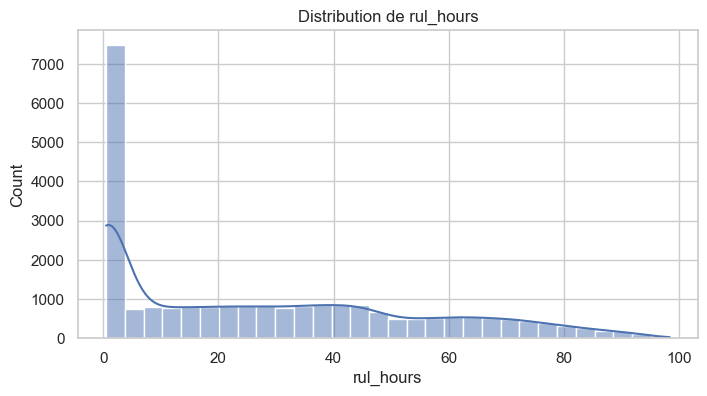

In [13]:
target = "rul_hours"

print(df[target].describe())

plt.figure(figsize=(8, 4))
sns.histplot(df[target], bins=30, kde=True)
plt.title("Distribution de rul_hours")
plt.xlabel("rul_hours")
plt.show()

In [14]:
numeric_features, categorical_features = get_feature_lists()
all_features = numeric_features + categorical_features

forbidden_cols = [
    "rul_hours",
    "failure_within_24h",
    "failure_type",
    "estimated_repair_cost",
    "health_index_ae",
    "health_status",
    "reconstruction_error",
    "reconstruction_error_norm",
]

features = [
    col for col in all_features
    if col in df.columns and col not in forbidden_cols
]

X = df[features].copy()
y = df[target].copy()

print("Nombre de features :", len(features))
print(features)
print("Shape X :", X.shape)
print("Shape y :", y.shape)

Nombre de features : 15
['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'temp_gap', 'vibration_rpm_interaction', 'pressure_current_interaction', 'vibration_delta', 'temperature_delta', 'anomaly_trend_raw', 'machine_type', 'operating_mode']
Shape X : (24042, 15)
Shape y : (24042,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train :", X_train.shape, y_train.shape)
print("Test  :", X_test.shape, y_test.shape)

Train : (19233, 15) (19233,)
Test  : (4809, 15) (4809,)


In [16]:
preprocessor = build_preprocessing_pipeline()
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['vibration_rms', 'temperature_motor',
                                  'current_phase_avg', 'pressure_level', 'rpm',
                                  'hours_since_maintenance', 'ambient_temp',
                                  'temp_gap', 'vibration_rpm_interaction',
                                  'pressure_current_interaction',
                                  'vibration_delta', 'temperature_delta',
                                  'anomaly_trend_raw']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                       

In [17]:
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        random_state=42
    ),

    "MLP Regressor": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=300,
        random_state=42
    )
}

In [18]:
def compute_regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

In [19]:
results = []
trained_models = {}
predictions = {}

for name, model in models.items():
    print(f"\nTraining : {name}")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae, rmse, r2 = compute_regression_metrics(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_models[name] = pipeline
    predictions[name] = y_pred

print("\nEntraînement terminé.")


Training : Linear Regression

Training : Random Forest

Training : Gradient Boosting

Training : MLP Regressor

Entraînement terminé.


In [20]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2
0,Random Forest,10.299331,15.198587,0.665914
1,MLP Regressor,12.945440,17.276414,0.568323
2,Gradient Boosting,13.828996,18.080656,0.527197
3,Linear Regression,20.449605,24.348558,0.142570


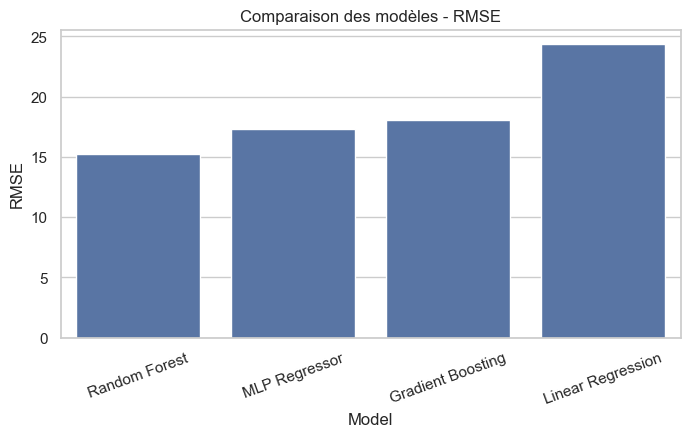

In [21]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("Comparaison des modèles - RMSE")
plt.xticks(rotation=20)
plt.show()

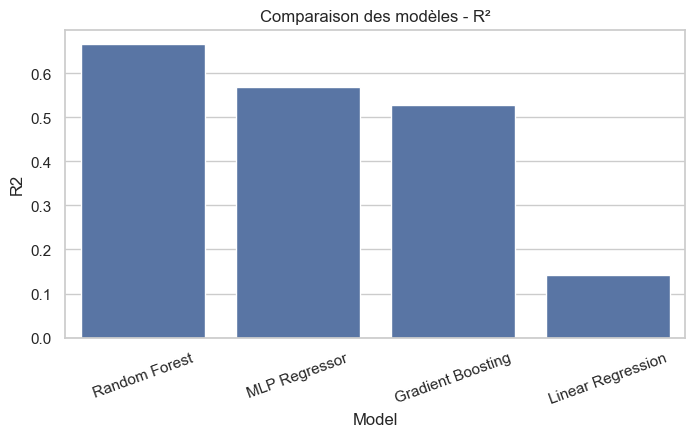

In [22]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="Model", y="R2")
plt.title("Comparaison des modèles - R²")
plt.xticks(rotation=20)
plt.show()

In [23]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Meilleur modèle RUL :", best_model_name)

Meilleur modèle RUL : Random Forest


In [24]:
y_pred_best = predictions[best_model_name]

df_compare = pd.DataFrame({
    "rul_true": y_test.values,
    "rul_pred": y_pred_best
})

df_compare.head()

,rul_true,rul_pred
0,0.50,12.182924
1,37.16,23.462861
2,0.50,1.724995
3,21.78,34.691710
4,33.24,27.925917


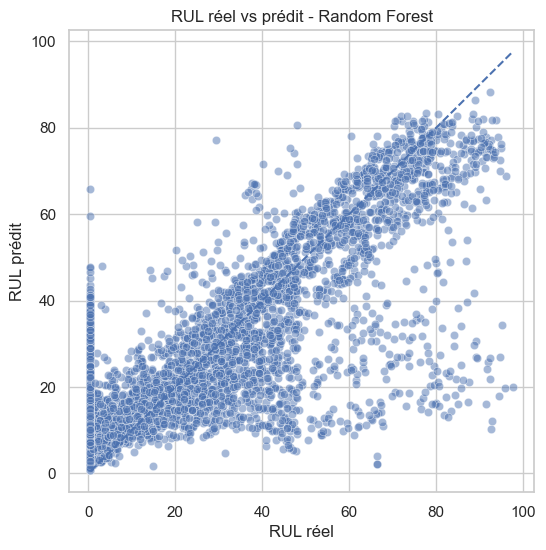

In [25]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df_compare, x="rul_true", y="rul_pred", alpha=0.5)
min_val = min(df_compare["rul_true"].min(), df_compare["rul_pred"].min())
max_val = max(df_compare["rul_true"].max(), df_compare["rul_pred"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title(f"RUL réel vs prédit - {best_model_name}")
plt.xlabel("RUL réel")
plt.ylabel("RUL prédit")
plt.show()

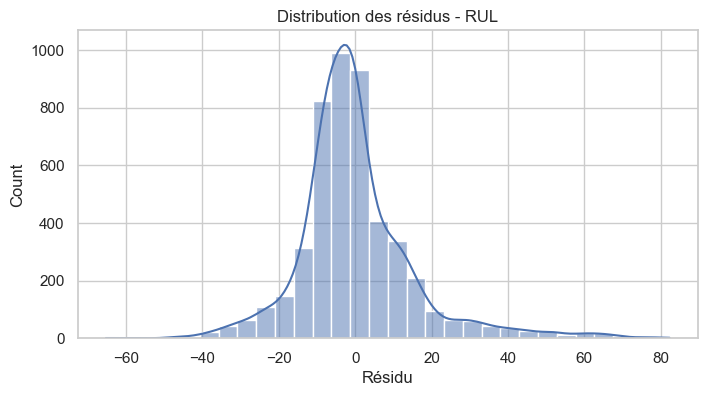

In [26]:
df_compare["residual"] = df_compare["rul_true"] - df_compare["rul_pred"]
df_compare["abs_error"] = np.abs(df_compare["residual"])

plt.figure(figsize=(8, 4))
sns.histplot(df_compare["residual"], bins=30, kde=True)
plt.title("Distribution des résidus - RUL")
plt.xlabel("Résidu")
plt.show()

In [27]:
joblib.dump(best_model, "../models/rul_regressor.joblib")
print("Modèle RUL sauvegardé dans models/rul_regressor.joblib")

Modèle RUL sauvegardé dans models/rul_regressor.joblib


In [28]:
results_df.to_csv("../reports/model_comparison_rul.csv", index=False)
print("Résultats sauvegardés dans reports/model_comparison_rul.csv")

Résultats sauvegardés dans reports/model_comparison_rul.csv


In [29]:
sample_input = X_test.head(5)

sample_pred = best_model.predict(sample_input)

pd.DataFrame({
    "rul_reel": y_test.head(5).values,
    "rul_predit": sample_pred
})

,rul_reel,rul_predit
0,0.50,12.182924
1,37.16,23.462861
2,0.50,1.724995
3,21.78,34.691710
4,33.24,27.925917


## Conclusion de la prédiction RUL

La prédiction du RUL (`rul_hours`) constitue une tâche plus complexe que la classification de panne, car elle repose sur l’estimation d’une durée de vie restante continue.

Les résultats montrent que le modèle Random Forest obtient les meilleures performances et parvient à capturer correctement la tendance générale du RUL.

Bien que certaines prédictions restent imprécises pour les cas extrêmes, cette approche permet d’obtenir une estimation pertinente de la durée de vie restante des machines dans un contexte de maintenance prédictive.
